In [9]:
import json
import pandas as pd

restaurants = []
for i in range(1,6):
        # Load JSON file
        with open(r'data\file{}.json'.format(i), "r", encoding="utf-8") as file:
            data = json.load(file)

        # Extract relevant information
        
        for item in data:  # data is a list, so iterate directly
            if isinstance(item, dict) and "restaurants" in item:  # Ensure correct structure
                for rest in item["restaurants"]:
                    restaurant = rest["restaurant"]
                    restaurants.append({
                        "ID": restaurant.get("id"),
                        "Name": restaurant.get("name"),
                        "Cuisines": restaurant.get("cuisines"),
                        "Address": restaurant["location"].get("address"),
                        "City": restaurant["location"].get("city"),
                        "Rating": restaurant["user_rating"].get("aggregate_rating"),
                        "Rating_text": restaurant["user_rating"].get("rating_text"),
                        "Votes": restaurant["user_rating"].get("votes"),
                        "Price Range": restaurant.get("price_range"),
                        "Latitude": restaurant["location"].get("latitude"),
                        "Longitude": restaurant["location"].get("longitude"),
                        "Online Delivery": "Yes" if restaurant.get("has_online_delivery") else "No",
                        "Table Booking": "Yes" if restaurant.get("has_table_booking") else "No",
                        "Average Cost for Two": restaurant.get("average_cost_for_two"),
                        "Photo_urls": restaurant.get("photos_url"),
                    })
# Convert to DataFrame
df = pd.DataFrame(restaurants)


df.head(10)  # Display the first 10 rows of the DataFrame


,ID,Name,Cuisines,Address,City,Rating,Rating_text,Votes,Price Range,Latitude,Longitude,Online Delivery,Table Booking,Average Cost for Two,Photo_urls
0,308322,Hauz Khas Social,"Continental, American, Asian, North Indian","9-A & 12, Hauz Khas Village, New Delhi",New Delhi,4.3,Very Good,7931,3,28.5542851000,77.1944706000,Yes,Yes,1600,https://www.zomato.com/HauzKhasSocial/photos?u...
1,18037817,Qubitos - The Terrace Cafe,"Thai, European, Mexican, North Indian, Chinese...","C-7, Vishal Enclave, Opposite Metro Pillar 417...",New Delhi,4.5,Excellent,778,3,28.6471325000,77.1177015000,No,Yes,1500,https://www.zomato.com/ncr/qubitos-the-terrace...
2,312345,The Hudson Cafe,"Cafe, Italian, Continental, Chinese","2524, 1st Floor, Hudson Lane, Delhi University...",New Delhi,4.4,Very Good,1537,2,28.6949468000,77.2043172000,Yes,No,850,https://www.zomato.com/ncr/the-hudson-cafe-del...
3,307490,Summer House Cafe,"Italian, Continental","1st Floor, DDA Shopping Complex, Aurobindo Pla...",New Delhi,4.1,Very Good,1823,3,28.5525204000,77.2038090000,No,Yes,1850,https://www.zomato.com/ncr/summer-house-cafe-h...
4,18241537,38 Barracks,"North Indian, Italian, Asian, American","M-38, Outer Circle, Connaught Place, New Delhi",New Delhi,4.4,Very Good,840,3,28.6330248887,77.2228584811,No,Yes,1600,https://www.zomato.com/ncr/38-barracks-connaug...
5,18161577,Spezia Bistro,"Cafe, Continental, Chinese, Italian","2525, 1st Floor, Hudson Lane, Delhi University...",New Delhi,4.6,Excellent,1071,2,28.6948390000,77.2041413000,Yes,Yes,900,https://www.zomato.com/ncr/spezia-bistro-delhi...
6,303960,Manhattan Brewery & Bar Exchange,"Finger Food, American, Continental, North Indi...","1st Floor, Global Foyer Mall, Sector 43, Golf ...",Gurgaon,4.6,Excellent,2093,4,28.4602710000,77.0950273000,No,No,2000,https://www.zomato.com/ncr/manhattan-brewery-b...
7,306134,The Wine Company,"Italian, European","Cyber Hub, DLF Cyber City, Gurgaon",Gurgaon,2.4,Poor,2412,4,28.4962285000,77.0890476000,No,Yes,2000,https://www.zomato.com/ncr/the-wine-company-dl...
8,18233593,Farzi Cafe,Modern Indian,"38/39, Level 1, Block E , Inner Circle, Connau...",New Delhi,4.4,Very Good,1942,4,28.6323984000,77.2214296000,No,No,2200,https://www.zomato.com/ncr/farzi-cafe-connaugh...
9,7528,Indian Grill Room,"North Indian, Mughlai","315, 3rd Floor, Suncity Business Tower, Golf C...",Gurgaon,4.5,Excellent,1262,3,28.4334574000,77.1052774000,Yes,Yes,1800,https://www.zomato.com/ncr/indian-grill-room-g...


In [7]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [8]:
# Save as CSV
df.to_sql('restaurants_table', con=engine, if_exists='replace', index=False)

29753

**Feature Engineering**

In [4]:
df.isnull().sum()  # Check for missing values

ID                      0
Name                    0
Cuisines                0
Address                 0
City                    0
Rating                  0
Rating_text             0
Votes                   0
Price Range             0
Online Delivery         0
Table Booking           0
Average Cost for Two    0
Photo_urls              0
dtype: int64

In [6]:
col = df.columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in col:
    df[i] = le.fit_transform(df[i])

In [9]:
df.to_sql('encoded_data', con=engine, if_exists='replace', index=False)

29753

In [10]:
selected_columns = [ 'Name', 'Cuisines', 'Address', 'City', 'Rating', 'Rating_text', 'Votes', 'Price Range', 'Online Delivery', 'Table Booking', 'Average Cost for Two']
df_selected = df[selected_columns]
df_selected.to_sql('features_for_model', con=engine, if_exists='replace', index=False)

29753

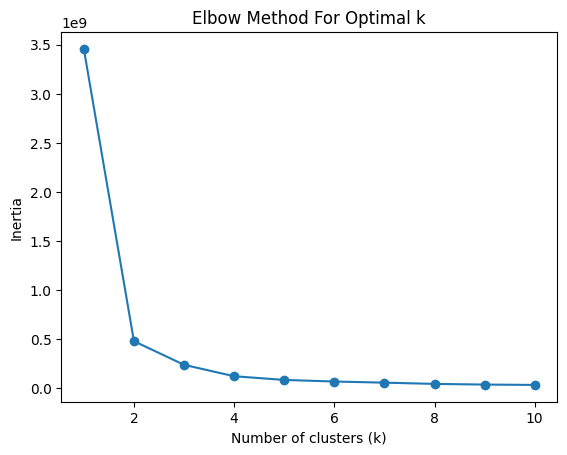

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

features = ['Rating', 'Votes', 'Price Range', 'Average Cost for Two']  # adjust as needed
X = df[features]

inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

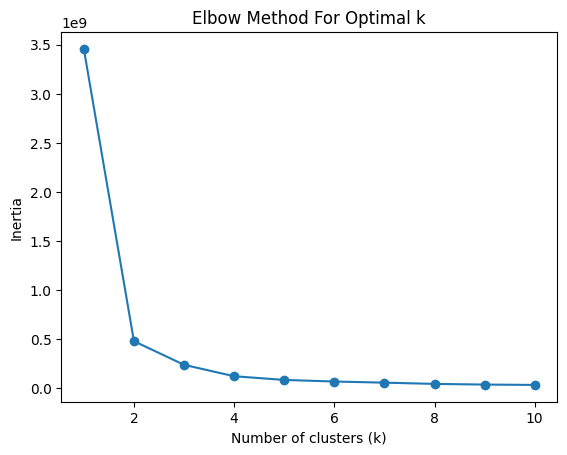

In [13]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

features = ['Rating', 'Votes', 'Price Range', 'Average Cost for Two']  # adjust as needed
X = df[features]

inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)


In [18]:
df['Cluster'].unique(
)

array([3, 0, 2, 4, 1], dtype=int32)

**Model Training**

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

def fit_model(df,n_clusters, random_state=42,model_save=False):
    
    
        kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)

    
        labels = kmeans.fit_predict(df)
        score = silhouette_score(df, labels)
        df['Cluster'] = labels
        return df
        if model_save==True:
            import joblib
            joblib.dump(kmeans, 'kmeans_model.pkl')    


    

In [26]:
fit_model(df_selected, n_clusters=5, random_state=42,model_save=True)

C:\Users\loges\AppData\Local\Temp\ipykernel_2624\1969744077.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = labels


,Name,Cuisines,Address,City,Rating,Rating_text,Votes,Price Range,Online Delivery,Table Booking,Average Cost for Two,Cluster
0,2892,628,3035,89,26,5,1011,2,1,1,84,1
1,5151,1812,4199,89,28,1,659,2,0,1,81,4
2,6676,428,1438,89,27,5,871,1,1,0,67,3
3,6148,1046,1015,89,24,5,912,2,0,1,89,3
4,51,1475,6144,89,27,5,687,2,0,1,84,0
...,...,...,...,...,...,...,...,...,...,...,...,...
29748,5642,1216,3106,102,19,2,108,0,0,0,0,3
29749,5553,98,616,102,19,2,85,2,0,0,8,3
29750,6391,16,2537,102,18,2,83,2,0,0,9,3
29751,5359,154,2753,102,19,2,91,0,0,0,2,3


In [28]:
df_selected.to_sql('clustered_data', con=engine, if_exists='replace', index=False)

29753

In [4]:
import webbrowser

latitude = 28.5542851
longitude =  77.1944706

google_maps_url = f"https://www.google.com/maps?q={latitude},{longitude}"
webbrowser.open(google_maps_url)

True